# **PENGELOMPOKAN PROVINSI DI INDONESIA BERDASARKAN POLA ADOPSI PEMBAYARAN DIGITAL TAHUN 2021-2025 MENGGUNAKAN ALGORITMA K-MEANS**

**Import Library dan Dataset**

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import RobustScaler
from yellowbrick.cluster import KElbowVisualizer

In [36]:
df = pd.read_excel('olah_data_fix.xlsx')

In [37]:
unique_provinces = df['Provinsi'].unique()
print("List of Provinces:")
for province in unique_provinces:
    print(province)

List of Provinces:
Bali
Banten
Bengkulu
D.I. Yogyakarta
DKI Jakarta
Gorontalo
Jambi
Jawa Barat
Jawa Tengah
Jawa Timur
Kalimantan Barat
Kalimantan Selatan
Kalimantan Tengah
Kalimantan Timur
Kalimantan Utara
Kep Bangka Belitung
Kepulauan Riau
Lampung
Maluku
Maluku Utara
Nanggroe Aceh Darussalam
Nusa Tenggara Barat
Nusa Tenggara Timur
Papua
Papua Barat
Riau
Sulawesi Barat
Sulawesi Selatan
Sulawesi Tengah
Sulawesi Tenggara
Sulawesi Utara
Sumatera Barat
Sumatera Selatan
Sumatera Utara


**Memahami Struktur Dataset**

In [38]:
df.head()

,Provinsi,Tahun,Bulan,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal
0,Bali,2021,January,208.867413,3.178836,1.034345,1489.401823
1,Bali,2021,February,606.522115,3.185314,1.077506,1386.998397
2,Bali,2021,March,940.731080,3.212755,1.171725,1691.743995
3,Bali,2021,April,1365.484745,3.187151,1.238369,1575.127704
4,Bali,2021,May,1381.959637,3.202142,1.311518,1502.116499


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Provinsi         2006 non-null   object 
 1   Tahun            2006 non-null   int64  
 2   Bulan            2006 non-null   object 
 3   outflow_tunai    2006 non-null   float64
 4   kartu_atm_debet  2006 non-null   float64
 5   Server_Based     2006 non-null   float64
 6   SKNBI_Asal       2006 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 109.8+ KB


In [40]:
df.describe()

,Tahun,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal
count,2006.000000,2006.000000,2006.000000,2006.000000,2.006000e+03
mean,2022.966102,1568.475427,7.877830,19.329419,1.322165e+04
std,1.402117,3040.248174,11.762223,87.940848,9.764998e+04
min,2021.000000,0.671077,0.000000,0.000000,1.662654e+01
25%,2022.000000,292.432176,1.832303,0.571756,4.744431e+02
50%,2023.000000,726.366085,3.778825,1.476751,1.038863e+03
75%,2024.000000,1438.946115,6.390947,4.066718,2.349098e+03
max,2025.000000,39563.616668,62.131953,678.661613,3.721066e+06


In [41]:
# Mengecek duplikat
df.duplicated(subset=['Provinsi', 'Tahun', 'Bulan']).sum()

np.int64(0)

**Eksplorasi Variabel Utama**

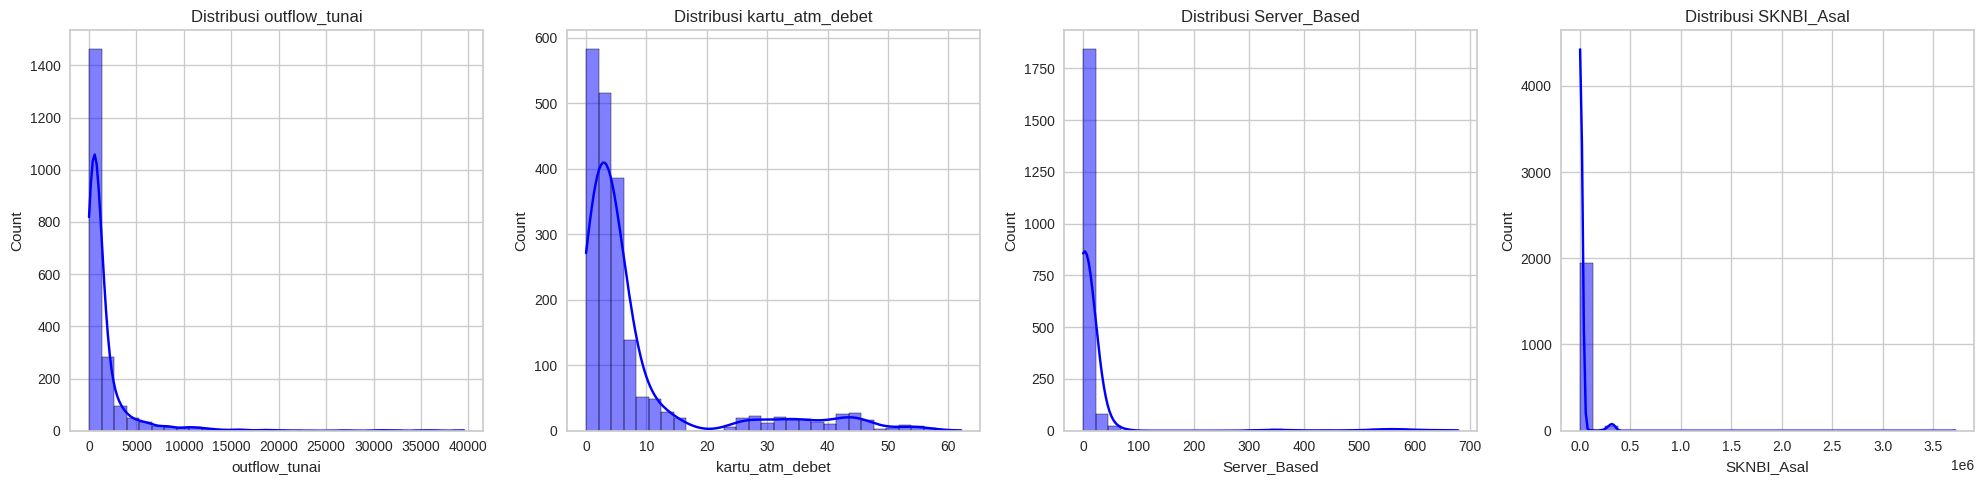

In [42]:
numeric_df =['outflow_tunai', 'kartu_atm_debet', 'Server_Based', 'SKNBI_Asal']

plt.figure(figsize=(20,5))
for i, column in enumerate(numeric_df, 1):
    plt.subplot(1, len(numeric_df), i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

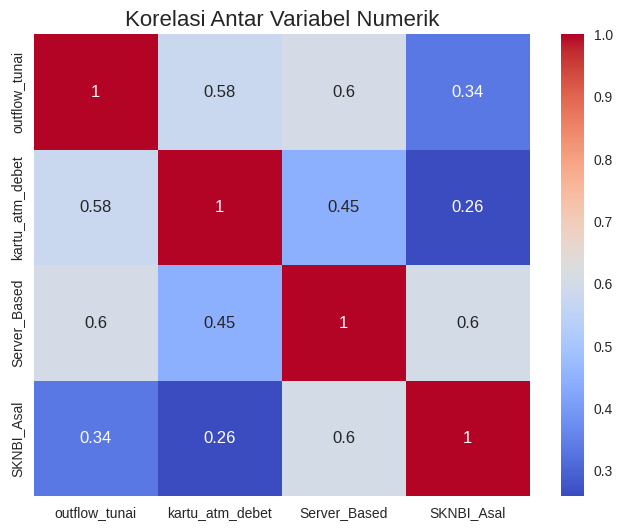

In [43]:
# Analisis hubungan antar variabel numerik
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_df].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Antar Variabel Numerik", fontsize=16)
plt.show()

In [44]:
# menghitung outlier tiap kolom numerik
for column in numeric_df:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Outliers pada kolom {column}: {outliers.shape[0]}")

Outliers pada kolom outflow_tunai: 219
Outliers pada kolom kartu_atm_debet: 272
Outliers pada kolom Server_Based: 288
Outliers pada kolom SKNBI_Asal: 313


**Transformasi Logaritmik**

In [45]:
df_agg = df.groupby(['Provinsi', 'Tahun'])[numeric_df].mean().reset_index()
df_agg.shape
df_agg.head()

,Provinsi,Tahun,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal
0,Bali,2021,902.600033,3.163470,1.458255,1671.728952
1,Bali,2022,1069.800820,3.754118,13.371114,3323.828403
2,Bali,2023,1146.025911,4.266522,1.621064,1799.206267
3,Bali,2024,1194.058522,4.807511,3.055586,1820.190503
4,Bali,2025,1068.412902,5.237269,3.524691,1568.389360


In [46]:
# menghitung outlier tiap kolom numerik setelah agregat
for column in numeric_df:
    Q1 = df_agg[column].quantile(0.25)
    Q3 = df_agg[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_agg[(df_agg[column] < lower_bound) | (df_agg[column] > upper_bound)]
    print(f"Outliers pada kolom {column} setelah agregat: {outliers.shape[0]}")

Outliers pada kolom outflow_tunai setelah agregat: 24
Outliers pada kolom kartu_atm_debet setelah agregat: 23
Outliers pada kolom Server_Based setelah agregat: 26
Outliers pada kolom SKNBI_Asal setelah agregat: 26


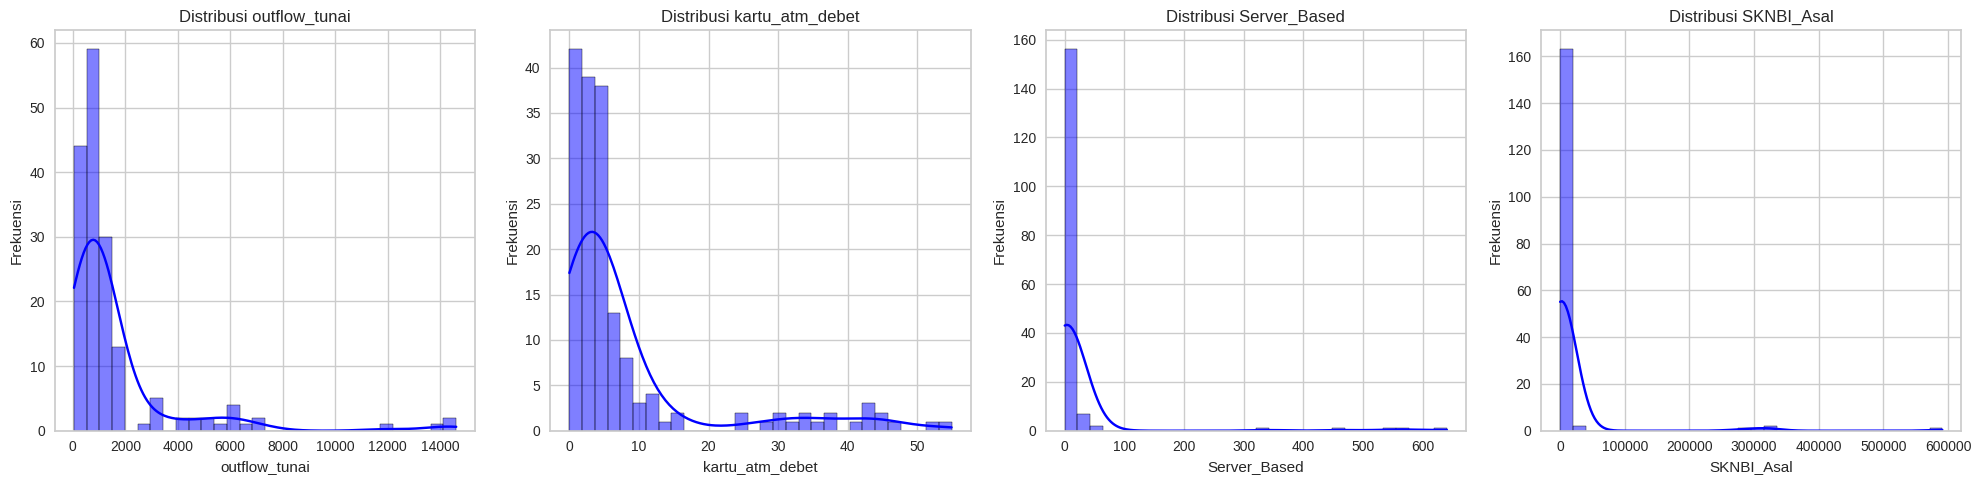

In [47]:
numeric_df = ['outflow_tunai', 'kartu_atm_debet', 'Server_Based', 'SKNBI_Asal']
plt.figure(figsize=(20, 5))
for i, column in enumerate(numeric_df, 1):
    plt.subplot(1, len(numeric_df), i)
    sns.histplot(df_agg[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
    plt.xlabel(column)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [48]:
skew_before = df_agg[numeric_df].skew()
for col in numeric_df:
    df_agg[col] = np.log1p(df_agg[col])
skew_after = df_agg[numeric_df].skew()
skewness_df = pd.DataFrame({
    'Sebelum Log-Transform': skew_before.round(2),
    'Setelah Log-Transform': skew_after.round(2)
})

skewness_df

,Sebelum Log-Transform,Setelah Log-Transform
outflow_tunai,3.66,0.50
kartu_atm_debet,2.40,0.84
Server_Based,5.87,2.16
SKNBI_Asal,6.60,0.99


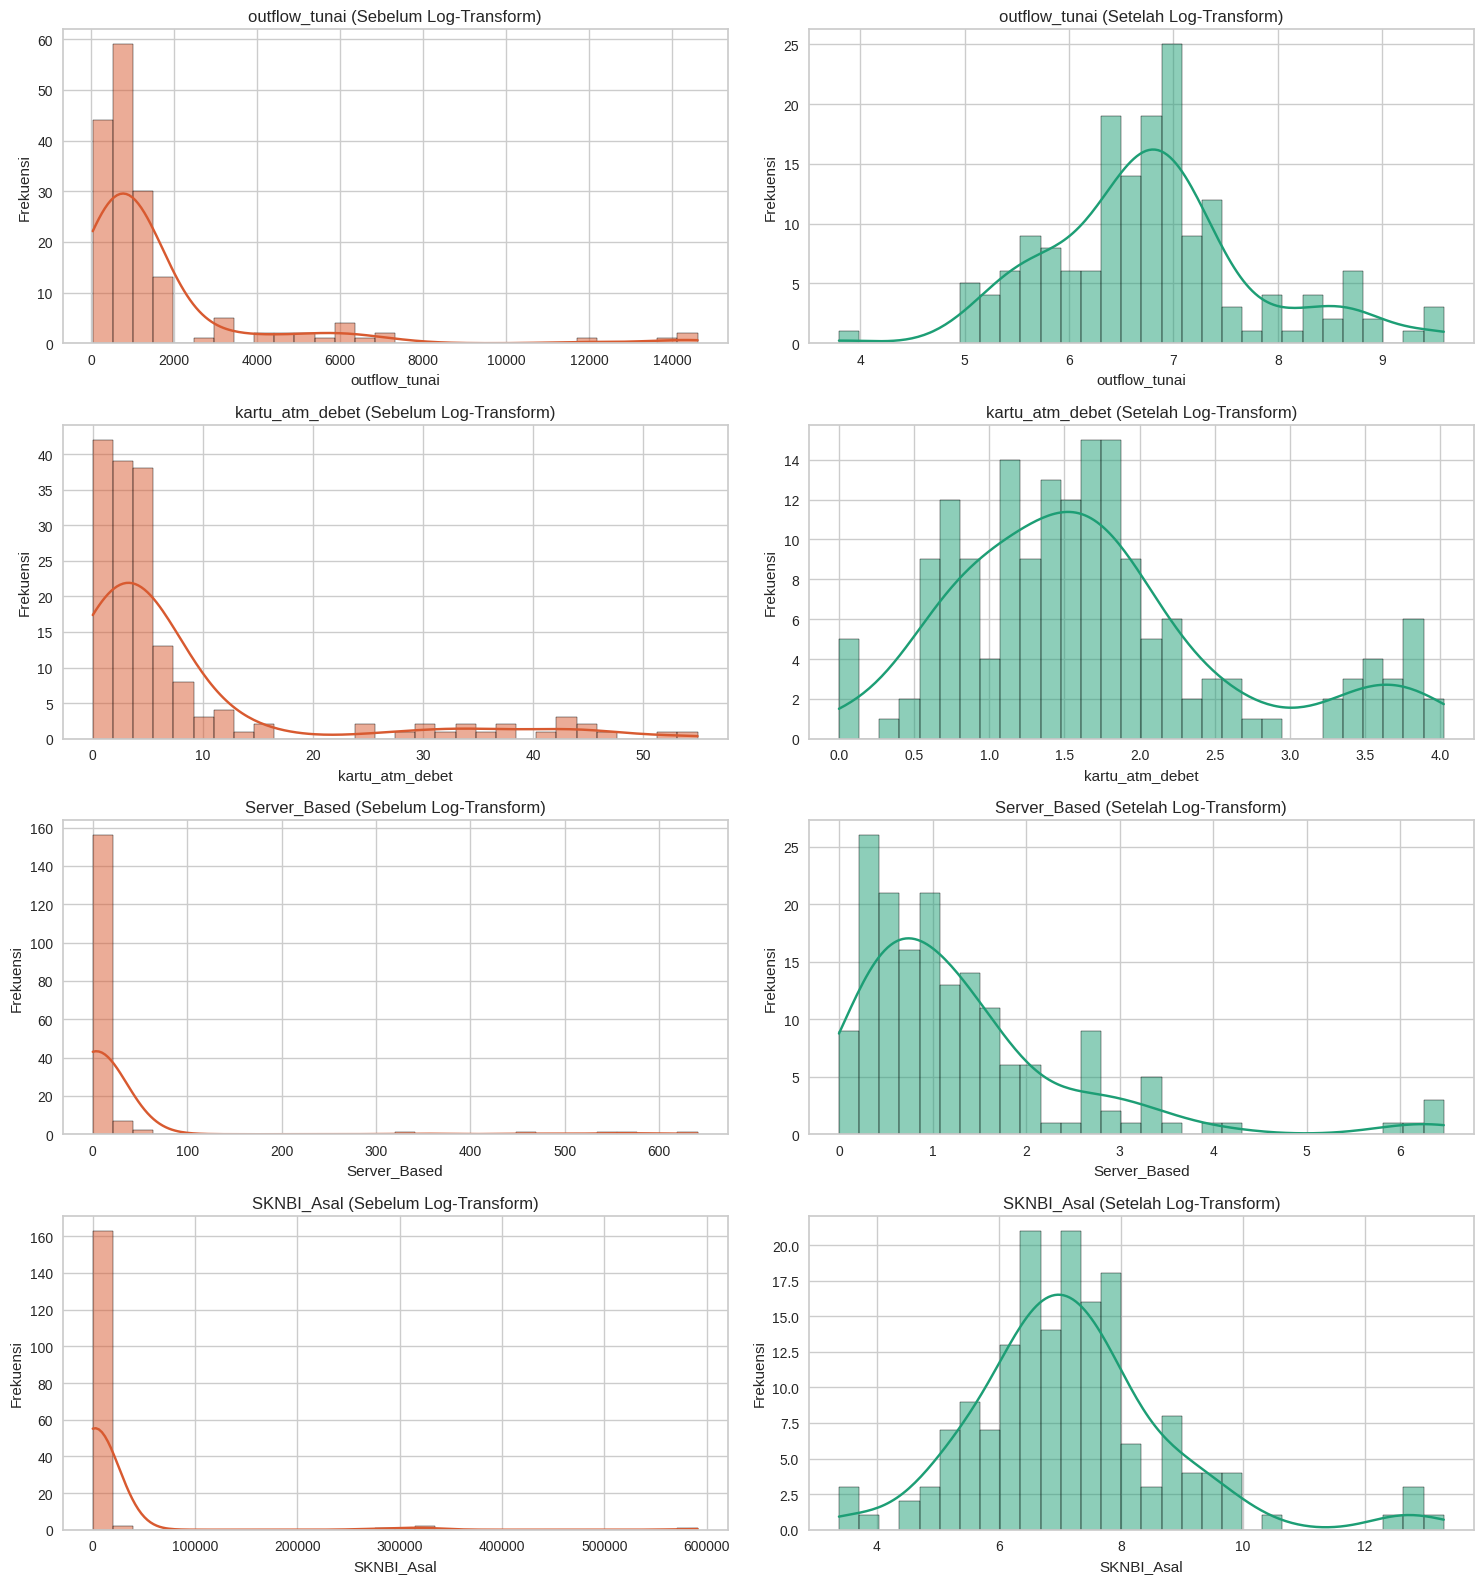

In [49]:
df_agg_before_log = df.groupby(['Provinsi', 'Tahun'])[numeric_df].mean().reset_index()
fig, axes = plt.subplots(len(numeric_df), 2, figsize=(15, 4*len(numeric_df)))
for i, col in enumerate(numeric_df):
    sns.histplot(df_agg_before_log[col], bins=30, kde=True, color='#D85A30', ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} (Sebelum Log-Transform)')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekuensi')
    sns.histplot(df_agg[col], bins=30, kde=True, color='#1D9E75', ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} (Setelah Log-Transform)')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [50]:
# menghitung outlier tiap kolom numerik setelah log tranform
for column in numeric_df:
    Q1 = df_agg[column].quantile(0.25)
    Q3 = df_agg[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_agg[(df_agg[column] < lower_bound) | (df_agg[column] > upper_bound)]
    print(f"Outliers pada kolom {column} setelah log transform: {outliers.shape[0]}")

Outliers pada kolom outflow_tunai setelah log transform: 13
Outliers pada kolom kartu_atm_debet setelah log transform: 17
Outliers pada kolom Server_Based setelah log transform: 9
Outliers pada kolom SKNBI_Asal setelah log transform: 10


**Standarisasi Data**

In [51]:
# Scaling dengan Robust scaler
scaler = RobustScaler()
X_all = scaler.fit_transform(df_agg[numeric_df])
df_agg['scaled_idx'] = range(len(df_agg))
#Melihat hasil scaling
scaled_df = pd.DataFrame(X_all, columns=numeric_df)
scaled_df.describe()

,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal
count,1.700000e+02,170.000000,170.000000,1.700000e+02
mean,1.900573e-02,0.114503,0.310650,7.430037e-02
std,1.023363e+00,1.001081,1.082479,1.073836e+00
min,-3.081089e+00,-1.692143,-0.860464,-2.436375e+00
25%,-6.034210e-01,-0.526598,-0.421378,-4.809401e-01
50%,4.601354e-16,0.000000,0.000000,-2.931683e-16
75%,3.965790e-01,0.473402,0.578622,5.190599e-01
max,2.923931e+00,2.665908,4.855608,4.111273e+00


**Membangun Model Clustering**

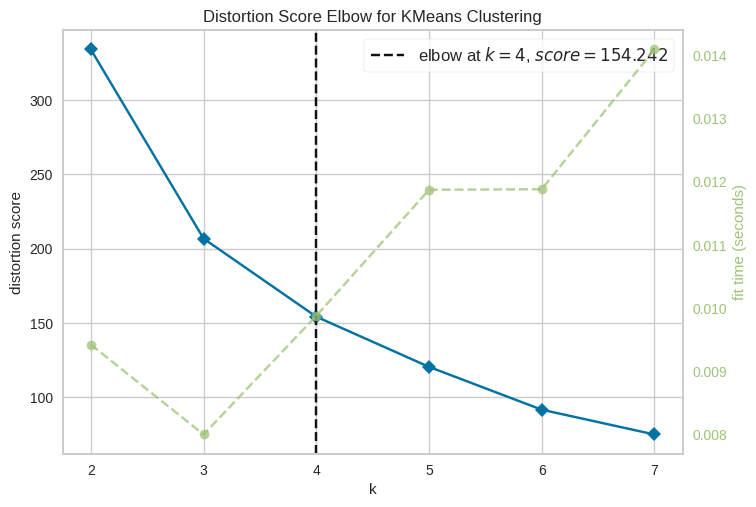

In [52]:
# Elbow Method
model = KMeans(random_state=42, n_init=10)
visualizer = KElbowVisualizer(model, k=(2, 8))
visualizer.fit(X_all)
visualizer.show()
optimal_k = visualizer.elbow_value_

In [53]:
k_values = visualizer.k_values_
wcss_scores = visualizer.k_scores_

df_elbow = pd.DataFrame({
    'Jumlah Klaster (K)': k_values,
    'WCSS (Distortion Score)': wcss_scores
})

print("Skor WCSS untuk masing-masing K:")
display(df_elbow.round(4))

Skor WCSS untuk masing-masing K:


,Jumlah Klaster (K),WCSS (Distortion Score)
0,2,333.9689
1,3,206.7872
2,4,154.2424
3,5,120.5053
4,6,91.7080
5,7,75.0433


In [54]:
years = sorted(df_agg['Tahun'].unique())
results_list = []
year_ref = years[0]
df_ref = df_agg[df_agg['Tahun'] == year_ref].copy()
idx_ref = df_ref['scaled_idx'].values
X_ref = X_all[idx_ref]

In [55]:
# Kmeans
kmeans_ref = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_ref = kmeans_ref.fit_predict(X_ref)
df_ref['Cluster_raw'] = labels_ref
results_list.append(df_ref)

In [56]:
# Centroid cluster
centroids_df = pd.DataFrame(kmeans_ref.cluster_centers_, columns=numeric_df)
display(centroids_df.round(2))

,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal
0,0.10,-0.09,-0.05,0.15
1,1.72,1.63,1.40,1.54
2,-3.08,2.42,4.30,3.61
3,-1.02,-1.06,-0.61,-0.70


In [57]:
# save csv centoroid cluster
centroids_df.to_csv('centroids_cluster.csv', index=False)
print('centroids_cluster.csv tersimpan —', centroids_df.shape)

centroids_cluster.csv tersimpan — (4, 4)


In [58]:
# Clustering tahunan dengan relabeling cluster
for year in years[1:]:
    df_yr = df_agg[df_agg['Tahun'] == year].copy()
    idx_yr = df_yr['scaled_idx'].values
    X_yr = X_all[idx_yr]
    km_yr = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels_yr = km_yr.fit_predict(X_yr)
    cost_matrix = euclidean_distances(km_yr.cluster_centers_, kmeans_ref.cluster_centers_)
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    label_map = {row: col for row, col in zip(row_ind, col_ind)}
    df_yr['Cluster_raw'] = [label_map[label] for label in labels_yr]
    results_list.append(df_yr)
df_clustered_yearly = pd.concat(results_list, ignore_index=True)
df_clustered_yearly.head()

,Provinsi,Tahun,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal,scaled_idx,Cluster_raw
0,Bali,2021,6.806387,1.426349,0.899452,7.422212,0,0
1,Banten,2021,7.034333,2.216910,1.954082,8.206279,5,0
2,Bengkulu,2021,6.347947,0.848629,0.480203,6.080326,10,3
3,D.I. Yogyakarta,2021,7.032741,1.627703,1.137183,7.379599,15,0
4,DKI Jakarta,2021,3.794308,3.794308,5.835846,12.532031,20,2


**Evaluasi Model Clustering**

**Validasi Multi-Metrik**

In [59]:
all_k_metrics_summary = []

for k in range(2, 8):
    current_k_results_list = []
    year_ref = years[0]
    df_ref = df_agg[df_agg['Tahun'] == year_ref].copy()
    idx_ref = df_ref['scaled_idx'].values
    X_ref = X_all[idx_ref]
    if k == 1:
        labels_ref = np.zeros(len(X_ref), dtype=int) # All in one cluster
        kmeans_ref_centers = X_ref.mean(axis=0).reshape(1, -1)
    else:
        kmeans_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_ref = kmeans_ref.fit_predict(X_ref)
        kmeans_ref_centers = kmeans_ref.cluster_centers_
    df_ref_clustered = df_ref.copy()
    df_ref_clustered['Cluster_raw'] = labels_ref
    current_k_results_list.append(df_ref_clustered)
    for year in years[1:]:
        df_yr = df_agg[df_agg['Tahun'] == year].copy()
        idx_yr = df_yr['scaled_idx'].values
        X_yr_inner = X_all[idx_yr]
        if k == 1:
            labels_yr_inner = np.zeros(len(X_yr_inner), dtype=int)
        else:
            km_yr = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels_yr_inner = km_yr.fit_predict(X_yr_inner)
            if len(np.unique(labels_yr_inner)) == k and k > 1:
                cost_matrix = euclidean_distances(km_yr.cluster_centers_, kmeans_ref_centers)
                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                label_map = {row: col for row, col in zip(row_ind, col_ind)}
                labels_yr_inner = np.array([label_map[label] for label in labels_yr_inner])
        df_yr_clustered = df_yr.copy()
        df_yr_clustered['Cluster_raw'] = labels_yr_inner
        current_k_results_list.append(df_yr_clustered)
    df_clustered_yearly_for_current_k = pd.concat(current_k_results_list, ignore_index=True)

    sorted_clustered_data = df_clustered_yearly_for_current_k.sort_values(by='scaled_idx')
    overall_labels = sorted_clustered_data['Cluster_raw'].values

    sil_score = np.nan
    ch_score = np.nan
    db_score = np.nan
    wcss_score = np.nan
    if k in df_elbow['Jumlah Klaster (K)'].values:
        wcss_score = df_elbow[df_elbow['Jumlah Klaster (K)'] == k]['WCSS (Distortion Score)'].values[0]
    if len(np.unique(overall_labels)) > 1 and len(X_all) > 1:
        sil_score = silhouette_score(X_all, overall_labels)
        ch_score = calinski_harabasz_score(X_all, overall_labels)
        db_score = davies_bouldin_score(X_all, overall_labels)
    all_k_metrics_summary.append({
        'K': k,
        'WCSS': wcss_score,
        'Silhouette Score': sil_score,
        'Calinski-Harabasz Score': ch_score,
        'Davies-Bouldin Score': db_score
    })

df_all_k_metrics = pd.DataFrame(all_k_metrics_summary)
df_all_k_metrics.set_index('K', inplace=True)

print("Tabel Evaluasi Klaster untuk K=2 sampai K=7 (Overall)")
display(df_all_k_metrics.round(4))

Tabel Evaluasi Klaster untuk K=2 sampai K=7 (Overall)


,WCSS,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
K,,,,
2,333.9689,0.6183,203.4651,0.6270
3,206.7872,0.3452,170.3999,0.8661
4,154.2424,0.4483,207.8932,0.7770
5,120.5053,0.3755,208.5189,0.8557
6,91.7080,0.3041,171.1461,1.0813
7,75.0433,0.3044,149.2448,1.7739


In [60]:
# Evaluasi stabilitas hasil cluster antar waktu
# WCSS, Silhouette, Calinski-Harabasz, Davies-Bouldin

metrics_results = []
for year in years:
    mask = df_clustered_yearly['Tahun'] == year
    idx = df_clustered_yearly[mask]['scaled_idx'].values
    X_yr = X_all[idx]
    labels_yr = df_clustered_yearly[mask]['Cluster_raw'].values
    if len(np.unique(labels_yr)) > 1 and len(X_yr) > 1:
        wcss_score = 0
        unique_labels_in_year = np.unique(labels_yr)
        cluster_centroids_for_year = {}

        for cluster_id in unique_labels_in_year:
            points_in_cluster = X_yr[labels_yr == cluster_id]
            if len(points_in_cluster) > 0:
                cluster_centroids_for_year[cluster_id] = points_in_cluster.mean(axis=0)
        for i in range(len(X_yr)):
            point = X_yr[i]
            assigned_cluster_id = labels_yr[i]
            if assigned_cluster_id in cluster_centroids_for_year:
                centroid = cluster_centroids_for_year[assigned_cluster_id]
                wcss_score += np.sum((point - centroid)**2)
        sil_score = silhouette_score(X_yr, labels_yr)
        ch_score = calinski_harabasz_score(X_yr, labels_yr)
        db_score = davies_bouldin_score(X_yr, labels_yr)
    else:
        wcss_score = np.nan
        sil_score = np.nan
        ch_score = np.nan
        db_score = np.nan
    metrics_results.append({
        'Tahun': year,
        'WCSS': wcss_score,
        'Silhouette Score': sil_score,
        'Calinski-Harabasz Score': ch_score,
        'Davies-Bouldin Score': db_score
    })
df_metrics = pd.DataFrame(metrics_results)
df_metrics.set_index('Tahun', inplace=True)
print("Klaster K=4")
display(df_metrics.round(4))

Klaster K=4


,WCSS,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
Tahun,,,,
2021,18.2045,0.4587,63.3552,0.5076
2022,25.5276,0.4109,45.5801,0.5614
2023,18.2128,0.4854,68.6326,0.4783
2024,19.7207,0.4924,65.3940,0.4727
2025,22.8123,0.4497,56.4187,0.5446


In [61]:
df_metrics.round(4).to_csv('metrics_results.csv')

**Interpretasi Hasil Clustering**

In [62]:
df_clustered_yearly.head()

,Provinsi,Tahun,outflow_tunai,kartu_atm_debet,Server_Based,SKNBI_Asal,scaled_idx,Cluster_raw
0,Bali,2021,6.806387,1.426349,0.899452,7.422212,0,0
1,Banten,2021,7.034333,2.216910,1.954082,8.206279,5,0
2,Bengkulu,2021,6.347947,0.848629,0.480203,6.080326,10,3
3,D.I. Yogyakarta,2021,7.032741,1.627703,1.137183,7.379599,15,0
4,DKI Jakarta,2021,3.794308,3.794308,5.835846,12.532031,20,2


In [63]:
# Perbandingan hasil cluster provinsi per tahun
comparison_table_raw = df_clustered_yearly.pivot_table(
    index='Provinsi',
    columns='Tahun',
    values='Cluster_raw',
    aggfunc='first'
)
comparison_table_raw

Tahun,2021,2022,2023,2024,2025
Provinsi,,,,,
Bali,0,0,0,0,0
Banten,0,0,0,0,0
Bengkulu,3,3,3,3,3
D.I. Yogyakarta,0,0,0,0,0
DKI Jakarta,2,2,2,2,2
Gorontalo,3,3,3,3,3
Jambi,0,0,0,0,0
Jawa Barat,1,1,1,1,1
Jawa Tengah,1,1,1,1,1


In [64]:
# Label semantik
label_mapping = {
    3: 'Digital Rendah',
    0: 'Digital Menengah',
    1: 'Digital Maju',
    2: 'Digital Spesialis Non-Tunai'
}
df_clustered_yearly['Target_Semantic'] = df_clustered_yearly['Cluster_raw'].map(label_mapping)

In [65]:
# Perbandingan hasil cluster provinsi per tahun dengan label semantik
comparison_table = df_clustered_yearly.pivot_table(
    index='Provinsi',
    columns='Tahun',
    values='Target_Semantic',
    aggfunc='first'
)
display(comparison_table)

Tahun,2021,2022,2023,2024,2025
Provinsi,,,,,
Bali,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah
Banten,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah
Bengkulu,Digital Rendah,Digital Rendah,Digital Rendah,Digital Rendah,Digital Rendah
D.I. Yogyakarta,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah
DKI Jakarta,Digital Spesialis Non-Tunai,Digital Spesialis Non-Tunai,Digital Spesialis Non-Tunai,Digital Spesialis Non-Tunai,Digital Spesialis Non-Tunai
Gorontalo,Digital Rendah,Digital Rendah,Digital Rendah,Digital Rendah,Digital Rendah
Jambi,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah,Digital Menengah
Jawa Barat,Digital Maju,Digital Maju,Digital Maju,Digital Maju,Digital Maju
Jawa Tengah,Digital Maju,Digital Maju,Digital Maju,Digital Maju,Digital Maju


In [66]:
# Perbandingan hasil cluster per tahun
cluster_counts_per_year = df_clustered_yearly.groupby(['Tahun', 'Target_Semantic']).size().reset_index(name='Count')

Klaster_per_tahun = cluster_counts_per_year.pivot_table(
    index='Target_Semantic',
    columns='Tahun',
    values='Count',
    fill_value=0
)
Klaster_per_tahun

Tahun,2021,2022,2023,2024,2025
Target_Semantic,,,,,
Digital Maju,4.0,4.0,4.0,4.0,4.0
Digital Menengah,19.0,20.0,20.0,20.0,16.0
Digital Rendah,10.0,9.0,9.0,9.0,13.0
Digital Spesialis Non-Tunai,1.0,1.0,1.0,1.0,1.0


**Analisis Perubahan Cluster Antar Tahun**

In [67]:
change_records = []
for i in range(len(years) - 1):
    y1, y2 = years[i], years[i + 1]
    changed = comparison_table[comparison_table[y1] != comparison_table[y2]]
    for prov, row in changed.iterrows():
        change_records.append({
            'Provinsi': prov,
            'Tahun Awal': y1,
            'Cluster Awal': row[y1],
            'Tahun Akhir': y2,
            'Cluster Akhir': row[y2]
        })
if change_records:
    df_changes = pd.DataFrame(change_records)
    display(df_changes)
else:
    print("Tidak ada perubahan klaster antar tahun.")

,Provinsi,Tahun Awal,Cluster Awal,Tahun Akhir,Cluster Akhir
0,Kalimantan Utara,2021,Digital Rendah,2022,Digital Menengah
1,Kalimantan Utara,2022,Digital Menengah,2023,Digital Rendah
2,Sulawesi Tengah,2022,Digital Rendah,2023,Digital Menengah
3,Nusa Tenggara Timur,2024,Digital Menengah,2025,Digital Rendah
4,Papua,2024,Digital Menengah,2025,Digital Rendah
5,Sulawesi Tengah,2024,Digital Menengah,2025,Digital Rendah
6,Sulawesi Utara,2024,Digital Menengah,2025,Digital Rendah


End of Code.